## Задача 1

Лесник решил провести кластеризацию животных по их расположению в лесу. Он разделил карту на квадраты по километровым отметкам: первый квадрат можно описать 0 ≤ x ≤ 1, 0 ≤ y ≤ 1, второй — 1 ≤ x ≤ 2,0 ≤ y ≤ 1 и так далее.

Для файла А леснику нужно определить два соседних квадрата, в которых суммарно находится больше всего животных. Для файла Б леснику нужно определить три соседних квадрата. Квадраты называются соседними, если у них есть общая граница.

Для каждого файла вычислите два числа: S — количество социальных животных в выбранных соседних квадратах, и K — количество остальных животных в выбранных соседних квадратах. Животное называется социальным, если в радиусе 0.1 вокруг него находится как минимум 14 других животных.

В ответе запишите четыре числа: в первой строке S и K для файла А, во второй строке аналогичные данные для файла Б.

Mounted at /content/drive


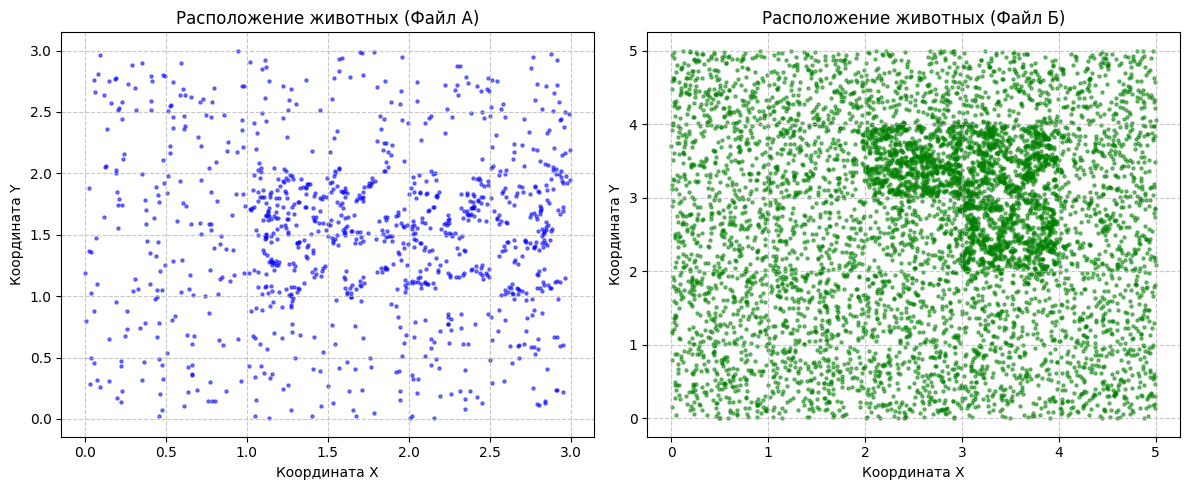

In [1]:
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

def read_points(file_path):
    x = []
    y = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip():
                coords = list(map(float, line.split()))
                x.append(coords[0])
                y.append(coords[1])
    return x, y

x_a, y_a = read_points('/content/drive/MyDrive/MachineLearning/more_ege/2_A.txt')
x_b, y_b = read_points('/content/drive/MyDrive/MachineLearning/more_ege/2_B.txt')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x_a, y_a, s=5, c='blue', alpha=0.5)
ax1.set_title('Файл A')
ax1.set_xlabel('Координата X')
ax1.set_ylabel('Координата Y')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(x_b, y_b, s=5, c='green', alpha=0.5)
ax2.set_title('Файл Б')
ax2.set_xlabel('Координата X')
ax2.set_ylabel('Координата Y')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [2]:
import math
from google.colab import drive

drive.mount('/content/drive')

def get_animal_stats(file_path, target_squares):
    points = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip():
                points.append(list(map(float, line.split())))

    n = len(points)
    is_social = [False] * n
    radius_sq = 0.1**2

    for i in range(n):
        count = 0
        xi, yi = points[i]
        for j in range(n):
            if i == j:
                continue
            dist_sq = (xi - points[j][0])**2 + (yi - points[j][1])**2
            if dist_sq <= radius_sq:
                count += 1
        if count >= 14:
            is_social[i] = True

    s_count = 0
    k_count = 0

    for i in range(n):
        x, y = points[i]
        in_target = False
        for (x_min, x_max, y_min, y_max) in target_squares:
            if x_min <= x <= x_max and y_min <= y <= y_max:
                in_target = True
                break

        if in_target:
            if is_social[i]:
                s_count += 1
            else:
                k_count += 1

    return s_count, k_count


squares_a = [(1, 2, 1, 2), (2, 3, 1, 2)]
squares_b = [(3, 4, 2, 3), (2, 3, 3, 4), (3, 4, 3, 4)]

s_a, k_a = get_animal_stats('/content/drive/MyDrive/MachineLearning/more_ege/1_A.txt', squares_a)
s_b, k_b = get_animal_stats('/content/drive/MyDrive/MachineLearning/more_ege/1_B.txt', squares_b)

print(f"{s_a} {k_a}")
print(f"{s_b} {k_b}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
104 453
2156 158


## Задача 2

Научно﻿-﻿исследовательский институт проводит мониторинг экологического состояния различных регионов. Результаты измерений представляются в виде пары чисел: первое — концентрация загрязняющего вещества в почве, второе — концентрация того же вещества в близлежащем водоёме. Для анализа результатов эта пара рассматривается как координаты точки на плоскости, и строится график с точками, которые соответствуют всем измерениям.

По ошибке данные нескольких исследуемых регионов были записаны в один файл. Известно, что измерения относятся к одному региону, если они образуют компактные группы точек на графике. Каждая группа лежит внутри прямоугольника высотой H и шириной.

Перед проведением основного анализа необходимо очистить данные от случайных выбросов при измерении. Для этого используется метод межквартильного размаха:
* для каждой группы точек вычисляется первый квартиль Q1 (значение, ниже которого находится 25% измерений) и третий квартиль Q3 (значение, выше которого находится 25% измерений) отдельно для рядов значений концентрации загрязняющего вещества в почве и в близлежащем водоёме (координаты X и Y)
* вычисляется межквартильный размах IQR - Q3 - Q1 для каждой кординаты
* точка считается выбросом, если хотя бы одна из её координат Х или Y выходит за пределы диапазона |Q1 - 1.5 * IQR; Q3 + 1.5 * IQR|

Для каждого региона необходимо рассчитать индекс экологической опасности I, который определяется как отношение среднего значения измерений к их количеству после удаления выбросов.

Под средним значением измерений в этом случае понимается среднее евклидово расстояние между всеми парами различных точек (измерений) в регионе.

В файле A хранятся данные о трёх регионах, где H=30, W=35. Каждая строка файла содержит два числа: координаты X (концентрация в почве) и Y (концентрация в водоёме), соответствующие одному измерению. Значения даны в условных единицах. Известно, что количество измерений не превышает 1000.

В файле B хранятся данные о пяти регионах, где H=40, W=32. Известно, что количество измерений не превышает 10000. Структура хранения информации в файле B аналогична файлу А.

Для каждого файла определите:
* общее количество выявленных выбросов
* регион с максимальным индексом экологической опасности

В ответе запишите четыре числа: в первой строке — общее количество выбросов и целую часть произведения I×100000 для файла A, во второй строке — аналогичные данные для файла B.

Расчёт квартилей
* Найдите медиану значений данных. Это второй квартиль Q2
* Найдите медиану значений данных, которые находятся ниже второго квартиля. Это первый квартиль Q1
* Найдите медиану значений данных, которые выше второго квартиля. Это третий квартиль Q3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


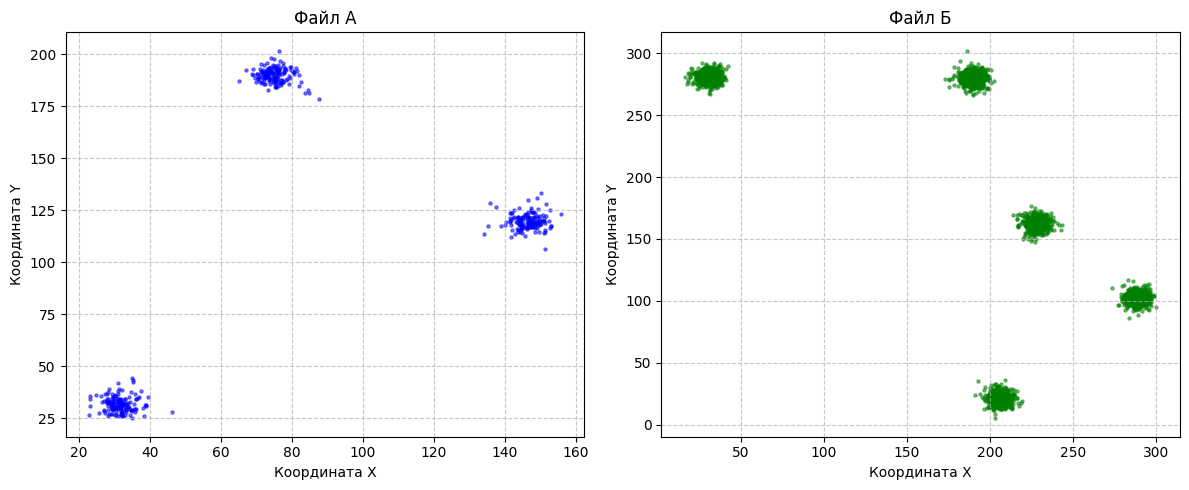

In [4]:
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

def read_points(file_path):
    x = []
    y = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip():
                coords = list(map(float, line.split()))
                x.append(coords[0])
                y.append(coords[1])
    return x, y

x_a, y_a = read_points('/content/drive/MyDrive/MachineLearning/more_ege/2_A.txt')
x_b, y_b = read_points('/content/drive/MyDrive/MachineLearning/more_ege/2_B.txt')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x_a, y_a, s=5, c='blue', alpha=0.5)
ax1.set_title('Файл A')
ax1.set_xlabel('Координата X')
ax1.set_ylabel('Координата Y')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(x_b, y_b, s=5, c='green', alpha=0.5)
ax2.set_title('Файл Б')
ax2.set_xlabel('Координата X')
ax2.set_ylabel('Координата Y')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
import math

def get_median(data):
    n = len(data)
    if n == 0: return 0
    sorted_data = sorted(data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        return (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2

def get_quartiles(data):
    q2 = get_median(data)
    low_part = [x for x in data if x < q2]
    high_part = [x for x in data if x > q2]
    q1 = get_median(low_part)
    q3 = get_median(high_part)
    return q1, q3

def solve(file_path, h, w):
    points = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip():
                points.append(list(map(float, line.split())))
    regions = []
    unvisited = set(range(len(points)))

    while unvisited:
        root_idx = unvisited.pop()
        current_region = [root_idx]
        stack = [root_idx]

        while stack:
            curr = stack.pop()
            to_remove = []
            for other in unvisited:
                dx = abs(points[curr][0] - points[other][0])
                dy = abs(points[curr][1] - points[other][1])
                if dx <= w and dy <= h:
                    current_region.append(other)
                    stack.append(other)
                    to_remove.append(other)
            for r in to_remove:
                unvisited.remove(r)
        regions.append([points[i] for i in current_region])

    total_outliers = 0
    max_index_val = -1

    for reg_points in regions:
        xs = [p[0] for p in reg_points]
        ys = [p[1] for p in reg_points]

        qx1, qx3 = get_quartiles(xs)
        qy1, qy3 = get_quartiles(ys)

        iqrx = qx3 - qx1
        iqry = qy3 - qy1

        filtered = []
        outliers_in_reg = 0

        for p in reg_points:
            is_outlier = False
            if not (qx1 - 1.5 * iqrx <= p[0] <= qx3 + 1.5 * iqrx):
                is_outlier = True
            if not (qy1 - 1.5 * iqry <= p[1] <= qy3 + 1.5 * iqry):
                is_outlier = True

            if is_outlier:
                outliers_in_reg += 1
            else:
                filtered.append(p)

        total_outliers += outliers_in_reg

        n_filtered = len(filtered)
        if n_filtered > 1:
            sum_dist = 0
            count_pairs = 0
            for i in range(n_filtered):
                for j in range(i + 1, n_filtered):
                    d = math.sqrt((filtered[i][0] - filtered[j][0])**2 +
                                  (filtered[i][1] - filtered[j][1])**2)
                    sum_dist += d
                    count_pairs += 1

            avg_dist = sum_dist / count_pairs
            idx_i = avg_dist / n_filtered
            if idx_i > max_index_val:
                max_index_val = idx_i

    return total_outliers, int(max_index_val * 100000)

res_a = solve('/content/drive/MyDrive/MachineLearning/more_ege/2_A.txt', 30, 35)
res_b = solve('/content/drive/MyDrive/MachineLearning/more_ege/2_B.txt', 40, 32)

print(f"{res_a[0]} {res_a[1]}")
print(f"{res_b[0]} {res_b[1]}")

25 3804
467 189


## Задача 3

Кластеризуйте как в предыдущих домашках. Будем называть центром кластера точку этого кластера, сумма расстояний от которой до всех остальных точек кластера минимальна.

Для каждого файла определите координаты центра каждого кластера, затем вычислите два числа: A - среднее арифметическое абсцисс центров кластеров, и среднее B - арифметическое ординат центров кластеров. В ответе запишите четыре числа: в первой строке сначала целую часть произведения A\*10000 затем целую часть произведения B\*10000 для файла А, во второй строке — аналогичные данные для файла Б.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


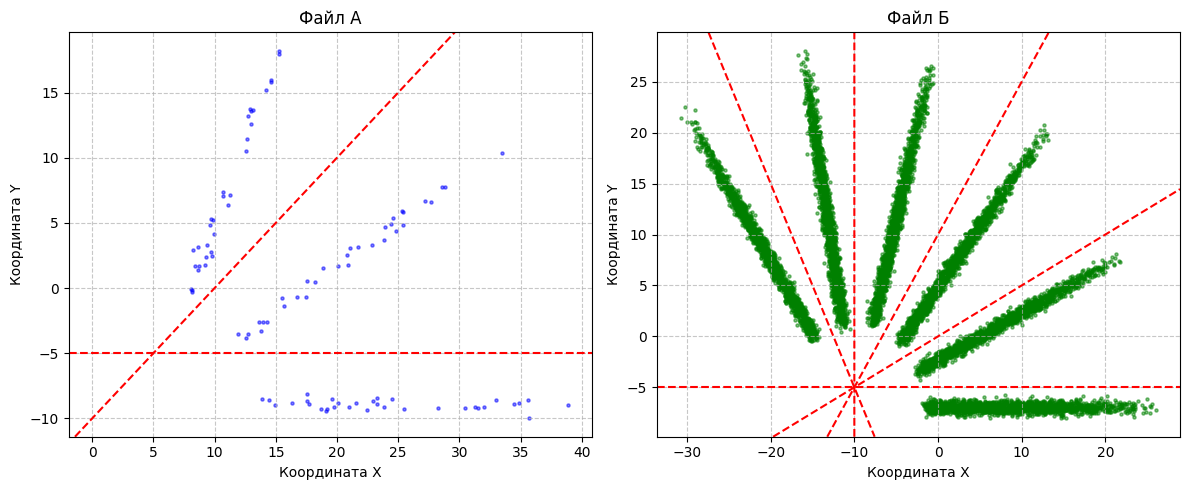

In [23]:
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

def read_points(file_path):
    x = []
    y = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                line = line.replace(',', '.')
                coords = list(map(float, line.split()))
                if len(coords) >= 2:
                    x.append(coords[0])
                    y.append(coords[1])
    return x, y

x_a, y_a = read_points('/content/drive/MyDrive/MachineLearning/more_ege/3_A.txt')
x_b, y_b = read_points('/content/drive/MyDrive/MachineLearning/more_ege/3_B.txt')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x_a, y_a, s=5, c='blue', alpha=0.5)
ax1.set_title('Файл A')
ax1.set_xlabel('Координата X')
ax1.set_ylabel('Координата Y')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axline((0, -10), slope=1, color='red', linestyle='--')
ax1.axline((0, -5), slope=0, color='red', linestyle='--')

ax2.scatter(x_b, y_b, s=5, c='green', alpha=0.5)
ax2.set_title('Файл Б')
ax2.set_xlabel('Координата X')
ax2.set_ylabel('Координата Y')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axline((-10, -5), slope=-2, color='red', linestyle='--')
ax2.axline((-10, -5), slope=100000, color='red', linestyle='--')
ax2.axline((-10, -5), slope=1.5, color='red', linestyle='--')
ax2.axline((-10, -5), slope=0.5, color='red', linestyle='--')
ax2.axline((-10, -5), slope=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [24]:
import math
from google.colab import drive
drive.mount('/content/drive')

def get_dist(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def find_cluster_center(points):
    min_sum = float('inf')
    center = points[0]

    for p1 in points:
        current_sum = sum(get_dist(p1, p2) for p2 in points)
        if current_sum < min_sum:
            min_sum = current_sum
            center = p1
    return center

def read_points(file_path):
    pnts = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                line = line.replace(',', '.')
                coords = list(map(float, line.split()))
                pnts.append(coords)
    return pnts

pntsa = read_points('/content/drive/MyDrive/MachineLearning/more_ege/3_A.txt')
pntsb = read_points('/content/drive/MyDrive/MachineLearning/more_ege/3_B.txt')

clA1 = [p for p in pntsa if p[1] >= p[0] - 10]
clA2 = [p for p in pntsa if p[1] < p[0] - 10 and p[1] >= -5]
clA3 = [p for p in pntsa if p[1] < -5]

cslA = [clA1, clA2, clA3]
centsA = []

for c in cslA:
    centsA.append(find_cluster_center(c))

avg_x = sum(p[0] for p in centsA) / len(centsA)
avg_y = sum(p[1] for p in centsA) / len(centsA)
print(int(avg_x * 10000), int(avg_y * 10000))

clB1 = [p for p in pntsb if p[1] + 5 <= -2*(p[0] + 10)]
clB2 = [p for p in pntsb if p[1] + 5 >= -2*(p[0] + 10) and p[0] <= -10]
clB3 = [p for p in pntsb if p[1] + 5 >= 1.5*(p[0] + 10) and p[0] >= -10]
clB4 = [p for p in pntsb if p[1] + 5 <= 1.5*(p[0] + 10) and p[1] + 5 >= 0.5*(p[0] + 10)]
clB5 = [p for p in pntsb if p[1] >= -5 and p[1] + 5 <= 0.5*(p[0] + 10)]
clB6 = [p for p in pntsb if p[1] <= -5]

cslB = [clB1, clB2, clB3, clB4, clB5, clB6]
centsB = []

for c in cslB:
    centsB.append(find_cluster_center(c))

avg_x = sum(p[0] for p in centsB) / len(centsB)
avg_y = sum(p[1] for p in centsB) / len(centsB)
print(int(avg_x * 10000), int(avg_y * 10000))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
178755 -2896
-37392 50998


## Задача 4

Исследователь анализирует набор объектов, каждый из которых характеризуется пятью числовыми параметрами. Он знает, что объекты образуют несколько групп (кластеров), которые можно выявить при проекции на плоскость только двух параметров из пяти. Значения в одном из столбцов будут соответствовать координатам по оси абсцисс, а из второго — координатам по оси ординат. Каждый кластер можно заключить в квадратную область заданного размера L, причём эти квадраты между собой не пересекаются. Стороны квадратов параллельны координатным осям. Каждый объект должен принадлежать только одному кластеру.

Евклидово расстояние

В файле A хранятся данные о наборе объектов, образующих три кластера. В каждой строке через пробел записаны пять параметров, характеризующих один объект. Все значения представлены с точностью до двух знаков после запятой. Количество объектов в файле А не превышает 1000.

В файле Б записаны данные о наборе объектов, образующих шесть кластеров, с аналогичной структурой хранения информации. Количество объектов в файле Б не превышает 10000.

Для каждого файла необходимо определить, какая пара параметров позволяет разделить объекты на кластеры, и найти минимальный размер стороны квадрата L, который может содержать все точки одного кластера при проекции на плоскость найденных параметров. Также определите в каждом кластере расстояние между двумя объектами, расположенными дальше всего друг от друга, и вычислите P — среднее арифметическое таких расстояний для всех кластеров.

В ответе запишите четыре числа: в первой строке — целую часть произведения L×10000, затем целую часть произведения P×10000 для файла А, во второй строке — аналогичные значения для файла Б.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


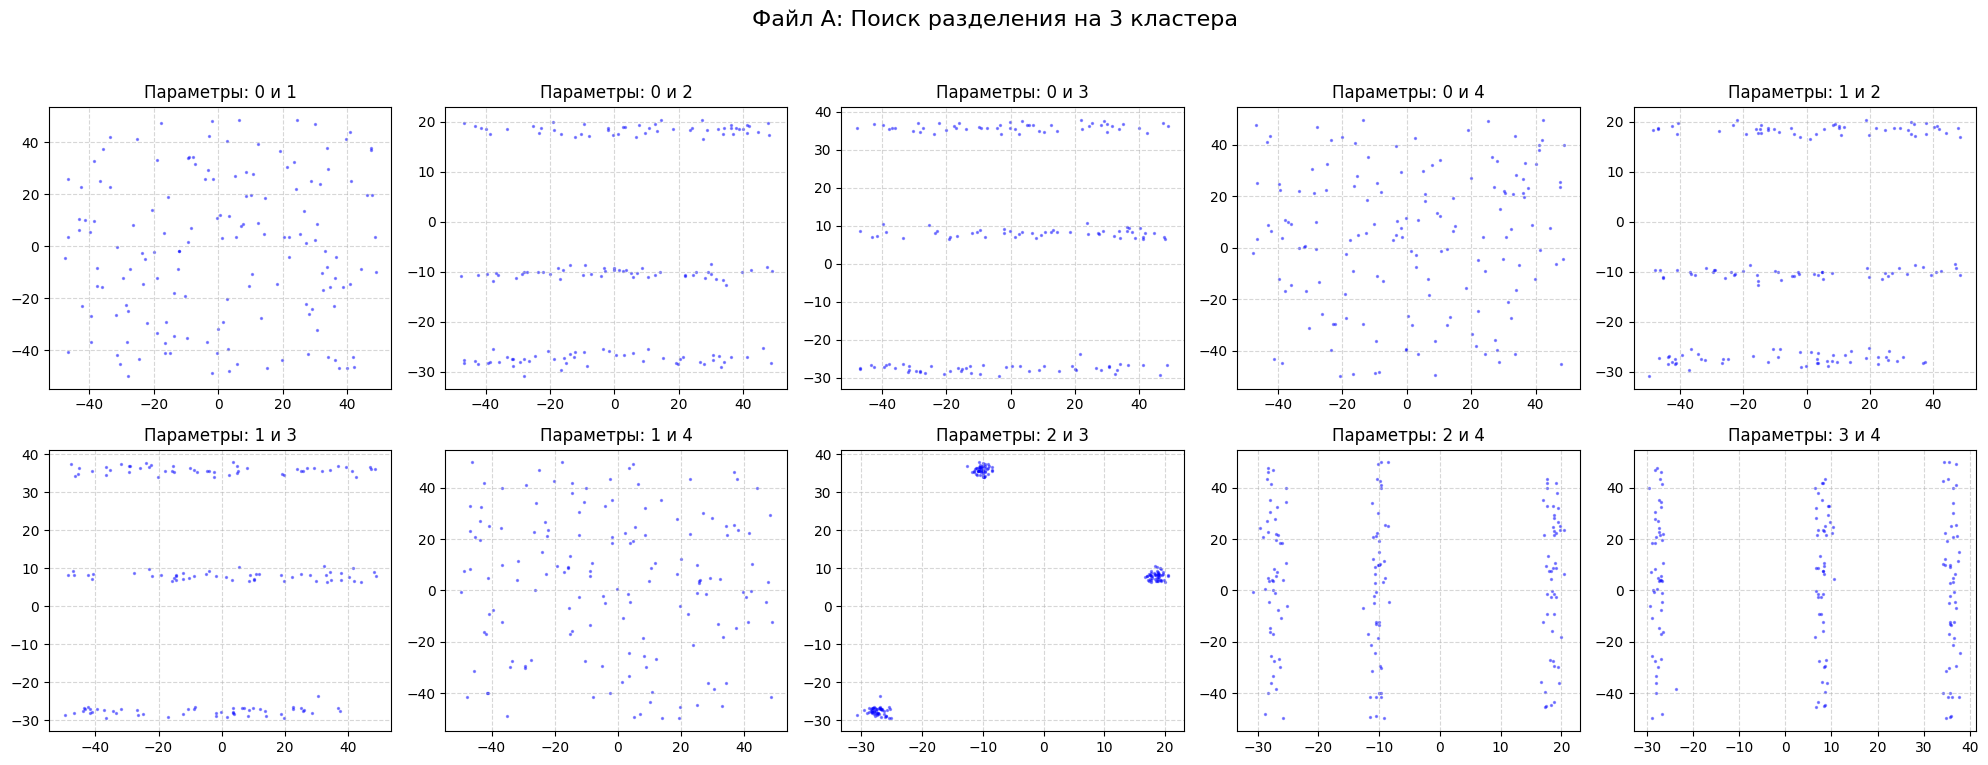

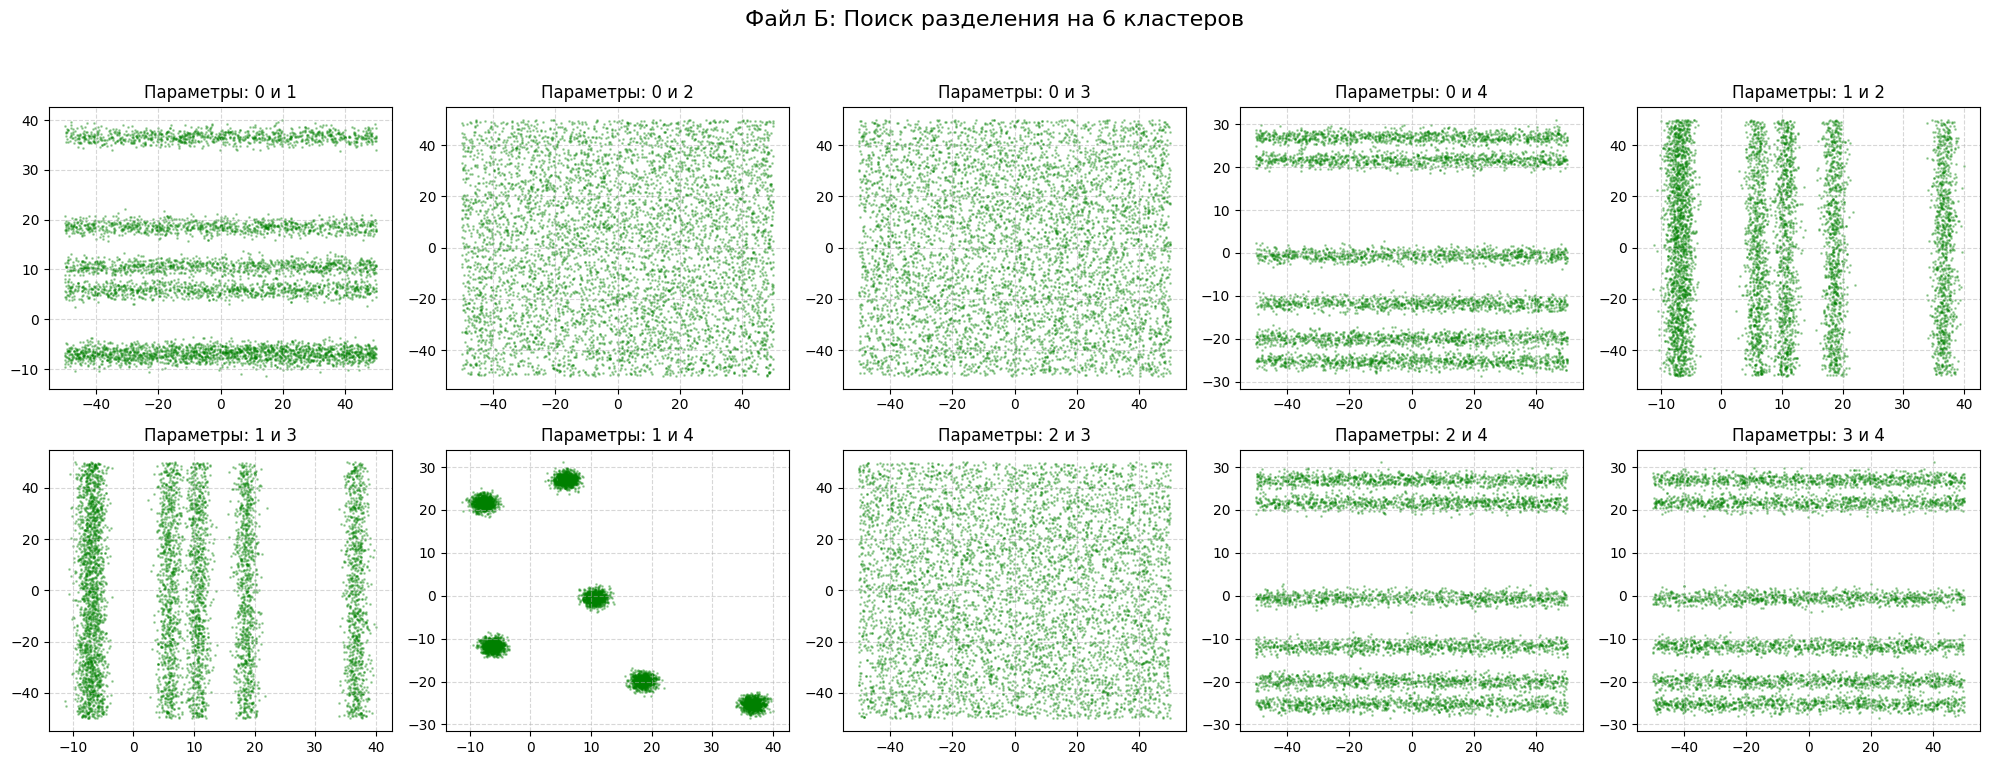

In [27]:
import matplotlib.pyplot as plt
import itertools
from google.colab import drive

drive.mount('/content/drive')

def read_all_params(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip():
                row = list(map(float, line.replace(',', '.').split()))
                data.append(row)
    return data

data_a = read_all_params('/content/drive/MyDrive/MachineLearning/more_ege/4_A.txt')
data_b = read_all_params('/content/drive/MyDrive/MachineLearning/more_ege/4_B.txt')

pairs = list(itertools.combinations(range(5), 2))

fig_a, axes_a = plt.subplots(2, 5, figsize=(20, 8))
fig_a.suptitle('Файл А: Поиск разделения на 3 кластера', fontsize=16)

for i, (idx1, idx2) in enumerate(pairs):
    ax = axes_a[i // 5, i % 5]
    x = [row[idx1] for row in data_a]
    y = [row[idx2] for row in data_a]
    ax.scatter(x, y, s=2, c='blue', alpha=0.4)
    ax.set_title(f'Параметры: {idx1} и {idx2}')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

fig_b, axes_b = plt.subplots(2, 5, figsize=(20, 8))
fig_b.suptitle('Файл Б: Поиск разделения на 6 кластеров', fontsize=16)

for i, (idx1, idx2) in enumerate(pairs):
    ax = axes_b[i // 5, i % 5]
    x = [row[idx1] for row in data_b]
    y = [row[idx2] for row in data_b]
    ax.scatter(x, y, s=1, c='green', alpha=0.3)
    ax.set_title(f'Параметры: {idx1} и {idx2}')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


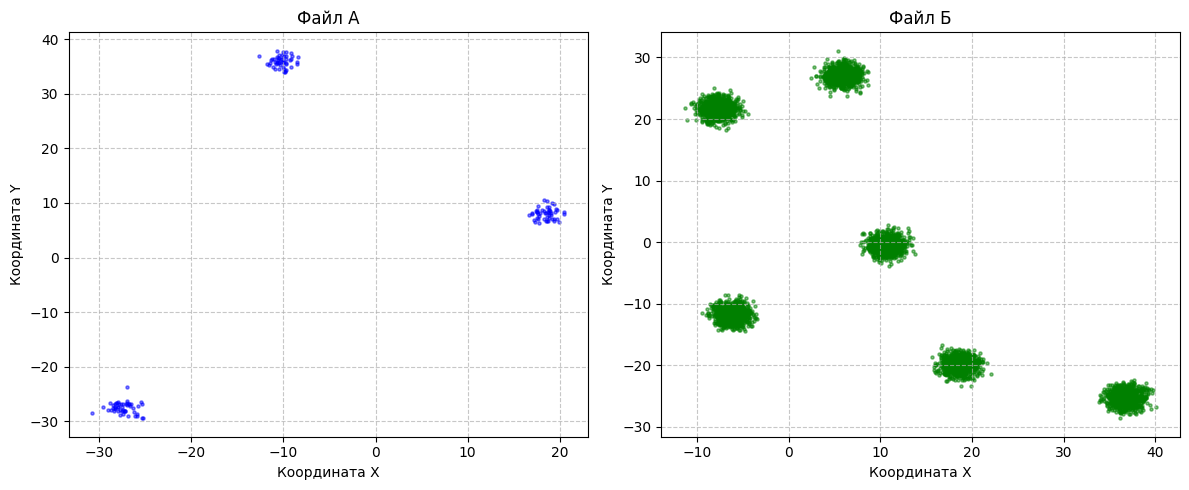

In [29]:
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

def read_columns(file_path, col1_idx, col2_idx):
    x = []
    y = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            line = line.replace(',', '.')
            coords = list(map(float, line.split()))
            x.append(coords[col1_idx])
            y.append(coords[col2_idx])
    return x, y

x_a, y_a = read_columns('/content/drive/MyDrive/MachineLearning/more_ege/4_A.txt', 2, 3)
x_b, y_b = read_columns('/content/drive/MyDrive/MachineLearning/more_ege/4_B.txt', 1, 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x_a, y_a, s=5, c='blue', alpha=0.5)
ax1.set_title('Файл A')
ax1.set_xlabel('Координата X')
ax1.set_ylabel('Координата Y')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.scatter(x_b, y_b, s=5, c='green', alpha=0.5)
ax2.set_title('Файл Б')
ax2.set_xlabel('Координата X')
ax2.set_ylabel('Координата Y')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

def read_columns(file_path, col1_idx, col2_idx):
    x = []
    y = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            line = line.replace(',', '.')
            coords = list(map(float, line.split()))
            x.append(coords[col1_idx])
            y.append(coords[col2_idx])
    return x, y

x_a, y_a = read_columns('/content/drive/MyDrive/MachineLearning/more_ege/4_A.txt', 2, 3)
x_b, y_b = read_columns('/content/drive/MyDrive/MachineLearning/more_ege/4_B.txt', 1, 4)


def get_dist(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def calculate_metrics(clusters):
    l_values = []
    p_values = []

    for cl in clusters:
        if not cl: continue

        min_x = min(p[0] for p in cl)
        max_x = max(p[0] for p in cl)
        min_y = min(p[1] for p in cl)
        max_y = max(p[1] for p in cl)
        l_values.append(max(max_x - min_x, max_y - min_y))

        max_d = 0
        for i in range(len(cl)):
            for j in range(i + 1, len(cl)):
                d = get_dist(cl[i], cl[j])
                if d > max_d:
                    max_d = d
        p_values.append(max_d)

    L = max(l_values)
    P = sum(p_values) / len(p_values)
    return L, P

# --- ФАЙЛ А ---
pntsa = list(zip(x_a, y_a))
clusters_a = [
    [p for p in pntsa if p[0] <= -20],
    [p for p in pntsa if p[0] > -20 and p[0] <= 0],
    [p for p in pntsa if p[0] > 0]
]

L_a, P_a = calculate_metrics(clusters_a)

# --- ФАЙЛ Б ---
pntsb = list(zip(x_b, y_b))
clusters_b = [
    [p for p in pntsb if p[0] <= 0 and p[1] >= 0],
    [p for p in pntsb if p[0] <= 0 and p[1] <= 0],
    [p for p in pntsb if p[0] >= 0 and p[1] >= 20],
    [p for p in pntsb if p[0] >= 0 and p[1] <= 20 and p[1] >= -10],
    [p for p in pntsb if p[0] >= 0 and p[0] <= 30 and p[1] <= -10],
    [p for p in pntsb if p[0] >= 30 and p[1] <= -10]
]

L_b, P_b = calculate_metrics(clusters_b)

print(int(L_a * 10000), int(P_a * 10000))
print(int(L_b * 10000), int(P_b * 10000))

Mounted at /content/drive
57999 49705
73500 68228


In [31]:
## Задача 5